In [1]:
 # import libraries
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import string
import re
import plotly.express as px

import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.probability import FreqDist
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


!pip install leia-br
from LeIA import SentimentIntensityAnalyzer

nltk.download('all')
nltk.download('stopwords')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.0/130.0 kB 2.6 MB/s eta 0:00:00


[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

In [2]:
from wordcloud import wordcloud

In [3]:
from google.colab import files
import pandas as pd

# Upload do arquivo CSV
uploaded = files.upload()

# Lê o arquivo CSV (substitua 'nome_do_arquivo.csv' pelo nome do seu arquivo)
file_name = next(iter(uploaded)) # Get the uploaded filename
df = pd.read_excel(file_name) # Changed to pd.read_excel assuming .xlsx format

# Mostra as primeiras linhas
df.head()

Saving sv_tweets_fev2026.xlsx to sv_tweets_fev2026.xlsx


,Query_Str,Post_URL,Author_Name,Author_Web_Page_URL,Author_Handle,Verified_Status,UTC_Time,Ads,Tweet_Content,Post_ID,...,View_Count,Bookmark_Count,Tweet_Image_URL,Replying_to,Reply_to_Whom,Reply_to_Whom_URL,Reply_to_Whom_Username,Reply_to_Whom_Handle,Language,Type
0,"china, israel","https://x.com/search?q=china, israel lang:pt u...",Noticias Militares,https://x.com/NoticiasMilita1,NoticiasMilita1,False,2026-02-27 21:15:00.000,False,"Canadá, países europeus e China pedem que cida...",2027537988251451492,...,11,0,NaN,False,NaN,NaN,NaN,NaN,pt,Top
1,"china, energia","https://x.com/search?q=china, energia lang:pt ...",Diário do Povo,https://x.com/DiarioPovo,DiarioPovo,False,2026-02-27 21:40:00.000,False,"Um pônei artesanal chamado #Mabiaobiao, que si...",2027544277174161481,...,120,0,https://pbs.twimg.com/media/HCJWCL1bUAA6V0z.jp...,False,NaN,NaN,NaN,NaN,pt,Top
2,"china, irã","https://x.com/search?q=china, irã lang:pt unti...",História com Palavrão 🇧🇷,https://x.com/damottaff,damottaff,True,2026-02-27 21:52:17.000,False,"O IRÃ NÃO aceitou a ""negociação"" do pedófilo. ...",2027547368334188736,...,577066,352,https://pbs.twimg.com/media/HCNLjr9XQAAzyiP.jp...,False,NaN,NaN,NaN,NaN,pt,Top
3,"china, irã","https://x.com/search?q=china, irã lang:pt unti...",Hugo Borges,https://x.com/hbj_r77032,hbj_r77032,True,2026-02-27 22:23:02.000,False,"A China está enviando ao Irã, materiais defens...",2027555106015605179,...,278,0,https://pbs.twimg.com/media/HCNR_iQWsAAD9Z9.jp...,False,NaN,NaN,NaN,NaN,pt,Top
4,"china, energia","https://x.com/search?q=china, energia lang:pt ...",CRI Português,https://x.com/criportugues,criportugues,False,2026-02-27 22:41:00.000,False,A energia limpa não apenas ilumina a paisagem ...,2027559628117270953,...,63,0,https://pbs.twimg.com/amplify_video_thumb/2021...,False,NaN,NaN,NaN,NaN,pt,Top


In [4]:
texto_limpo = set (stopwords.words('portuguese'))
stop_extra = {'pra', 'q' }
texto_limpo = texto_limpo.union(stop_extra)

In [5]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Baixar o necessário
nltk.download('stopwords')
nltk.download('punkt')

# Obter e estender lista NLTK
stop_words = set(stopwords.words('portuguese'))
girias = {'vc', 'vcs', 'tá', 'bora', 'mano', 'kkk', 'né', 'vlw', 'eita', 'uai', 'pra', 'q'}
stop_words.update(girias)

# Função de remoção
def remover_stopwords_pt(texto):
    tokens = word_tokenize(texto.lower())
    return " ".join([p for p in tokens if p not in stop_words])

# Exemplo
frase = "Vlw mano, td blz?"
print(f"Limpo: {remover_stopwords_pt(frase)}")

Limpo: , td blz ?


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [6]:
df = df.drop([ 'Post_URL', 'Author_Name', 'Author_Web_Page_URL', 'Author_Handle', 'Verified_Status', 'UTC_Time', 'Ads', 'View_Count', 'Bookmark_Count', 'Tweet_Image_URL', 'Replying_to',
              'Reply_to_Whom', 'Reply_to_Whom_URL', 'Reply_to_Whom_Username', 'Reply_to_Whom_Handle', 'Language', 'Type', 'Tweet_URL'],  axis=1, errors='ignore')
df.head()

,Query_Str,Tweet_Content,Post_ID,Reply_Count,Repost_Count,Like_Count
0,"china, israel","Canadá, países europeus e China pedem que cida...",2027537988251451492,0,0,1
1,"china, energia","Um pônei artesanal chamado #Mabiaobiao, que si...",2027544277174161481,0,0,0
2,"china, irã","O IRÃ NÃO aceitou a ""negociação"" do pedófilo. ...",2027547368334188736,433,535,7385
3,"china, irã","A China está enviando ao Irã, materiais defens...",2027555106015605179,0,0,6
4,"china, energia",A energia limpa não apenas ilumina a paisagem ...,2027559628117270953,0,0,2


In [7]:
def pre_processamento(texto):

    # seleciona apenas letras e coloca todas em minúsculo
    letras_min =  re.findall(r'\b[A-zÀ-úü]+\b', texto.lower())

    # remove stopwords
    stopwords = nltk.corpus.stopwords.words('portuguese')
    stop = set(stopwords)
    sem_stopwords = [w for w in letras_min if w not in stop]

    # juntando os tokens novamente em formato de texto
    texto_limpo = " ".join(sem_stopwords)

    return texto_limpo

In [8]:
# A coluna 'Tweet_Content' foi removida em uma etapa anterior.
# Se a coluna 'tokens' já contém os dados processados, a linha abaixo é redundante e causará um erro.
# Se você pretende re-processar o texto, será necessário recarregar o dataframe ou usar uma coluna existente.
# df['tokens'] = df['Tweet_Content'].apply(pre_processamento)
df.head()

,Query_Str,Tweet_Content,Post_ID,Reply_Count,Repost_Count,Like_Count
0,"china, israel","Canadá, países europeus e China pedem que cida...",2027537988251451492,0,0,1
1,"china, energia","Um pônei artesanal chamado #Mabiaobiao, que si...",2027544277174161481,0,0,0
2,"china, irã","O IRÃ NÃO aceitou a ""negociação"" do pedófilo. ...",2027547368334188736,433,535,7385
3,"china, irã","A China está enviando ao Irã, materiais defens...",2027555106015605179,0,0,6
4,"china, energia",A energia limpa não apenas ilumina a paisagem ...,2027559628117270953,0,0,2


🔠 Palavras mais frequentes:
[('china', 5091), ('eua', 2833), ('irã', 2501), ('guerra', 966), ('rússia', 943), ('israel', 931), ('trump', 779), ('brasil', 752), ('petróleo', 747), ('estreito', 615)]


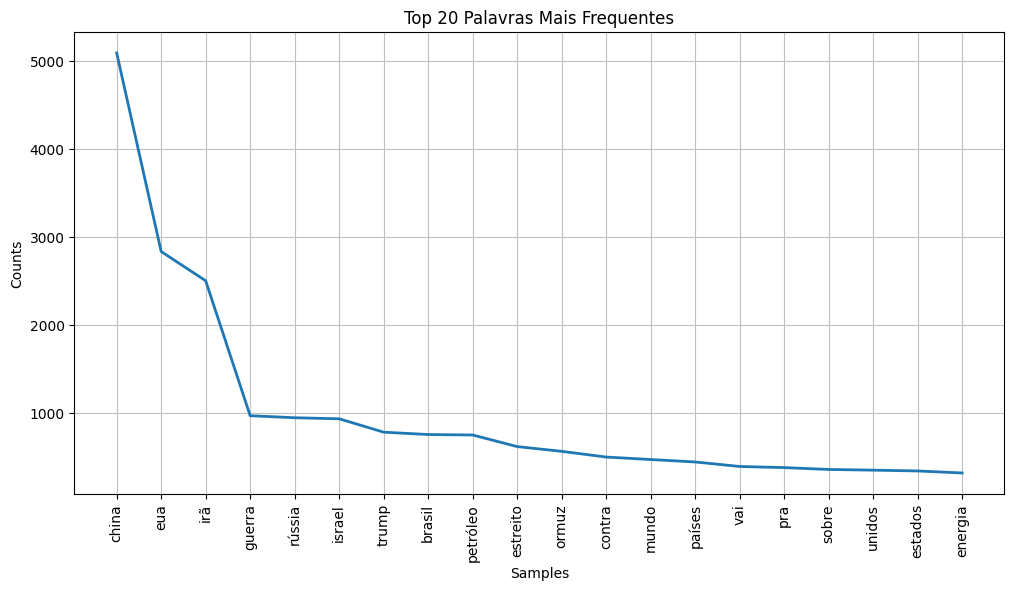

In [9]:
df['tokens'] = df['Tweet_Content'].apply(pre_processamento)

all_words = [word for text_string in df['tokens'] for word in text_string.split(" ")]

freq_dist = FreqDist(all_words)

print("🔠 Palavras mais frequentes:")
print(freq_dist.most_common(10))

# Plotagem do gráfico
plt.figure(figsize=(12, 6))
freq_dist.plot(20, title='Top 20 Palavras Mais Frequentes', cumulative=False)
plt.show()

In [10]:
from collections import Counter
word_counts = Counter(all_words)
print(word_counts.most_common(23)) # Top 10 palavras mais frequentes

[('china', 5091), ('eua', 2833), ('irã', 2501), ('guerra', 966), ('rússia', 943), ('israel', 931), ('trump', 779), ('brasil', 752), ('petróleo', 747), ('estreito', 615), ('ormuz', 561), ('contra', 496), ('mundo', 468), ('países', 440), ('vai', 389), ('pra', 376), ('sobre', 355), ('unidos', 347), ('estados', 338), ('energia', 315), ('agora', 305), ('país', 304), ('pode', 301)]


In [11]:
sia = SentimentIntensityAnalyzer()

def get_compound_Sentimento(texto):
  sentimento = sia.polarity_scores(texto)
  return sentimento['compound']

def get_neg_Sentimento(texto):
  sentimento = sia.polarity_scores(texto)
  return sentimento['neg']

def get_neu_Sentimento(texto):
  sentimento = sia.polarity_scores(texto)
  return sentimento['neu']

def get_pos_Sentimento(texto):
  sentimento = sia.polarity_scores(texto)
  return sentimento['pos']

def get_all_Sentimento(texto):
  sentimento = sia.polarity_scores(texto)
  return sentimento

In [12]:
df['sentimento'] = df['tokens'].apply(get_compound_Sentimento)
df['negativo']  = df['tokens'].apply(get_neg_Sentimento)
df['positivo']  = df['tokens'].apply(get_pos_Sentimento)
df['neutro']    = df['tokens'].apply(get_neu_Sentimento)
df.head()

,Query_Str,Tweet_Content,Post_ID,Reply_Count,Repost_Count,Like_Count,tokens,sentimento,negativo,positivo,neutro
0,"china, israel","Canadá, países europeus e China pedem que cida...",2027537988251451492,0,0,1,canadá países europeus china pedem cidadãos de...,0.0000,0.000,0.000,1.000
1,"china, energia","Um pônei artesanal chamado #Mabiaobiao, que si...",2027544277174161481,0,0,0,pônei artesanal chamado mabiaobiao significa p...,0.2960,0.000,0.109,0.891
2,"china, irã","O IRÃ NÃO aceitou a ""negociação"" do pedófilo. ...",2027547368334188736,433,535,7385,irã aceitou negociação pedófilo eua autorizara...,-0.4588,0.090,0.037,0.873
3,"china, irã","A China está enviando ao Irã, materiais defens...",2027555106015605179,0,0,6,china enviando irã materiais defensivos ofensi...,-0.5267,0.227,0.000,0.773
4,"china, energia",A energia limpa não apenas ilumina a paisagem ...,2027559628117270953,0,0,2,energia limpa apenas ilumina paisagem noturna ...,0.6369,0.000,0.341,0.659


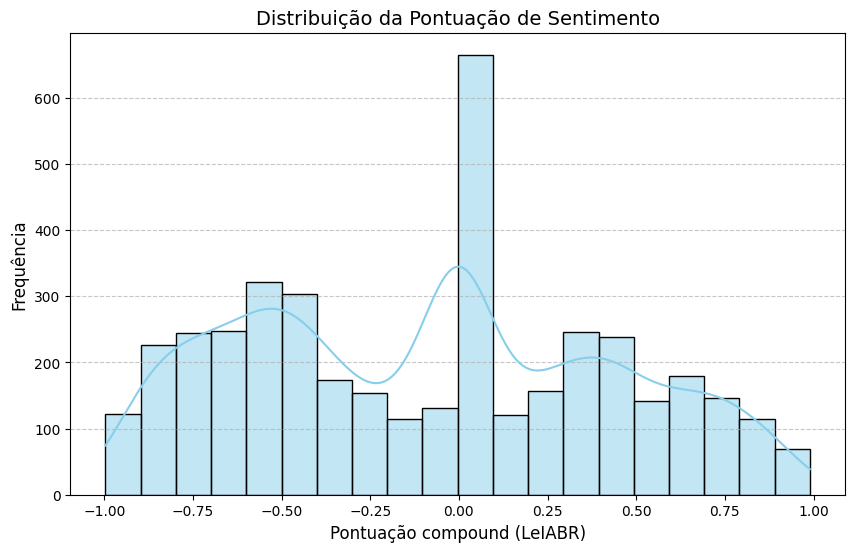

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['sentimento'], bins=20, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribuição da Pontuação de Sentimento', fontsize=14)
plt.xlabel('Pontuação compound (LeIABR)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

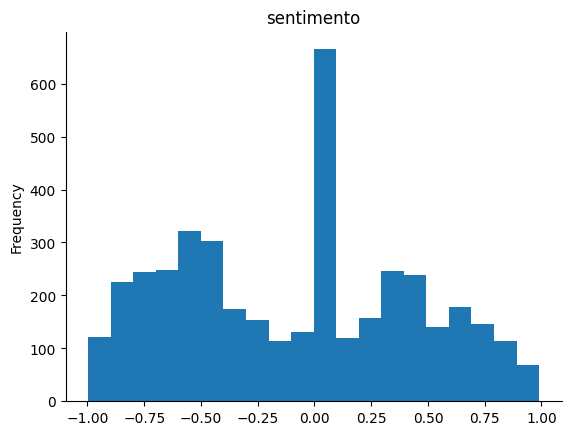

In [15]:
from matplotlib import pyplot as plt
df['sentimento'].plot(kind='hist', bins=20, title='sentimento')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [16]:
import matplotlib.colors as mcolors

# Definindo as cores em RGB (valores entre 0 e 1) ou em hexadecimal
laranja = '#ad2a00'   # Laranja
verde_jade = '#044020' # Verde jade
dourado = '#c48831'

# Criando o colormap personalizado
cmap_laranja_jade = mcolors.LinearSegmentedColormap.from_list('laranja_jade', [laranja, verde_jade, dourado])

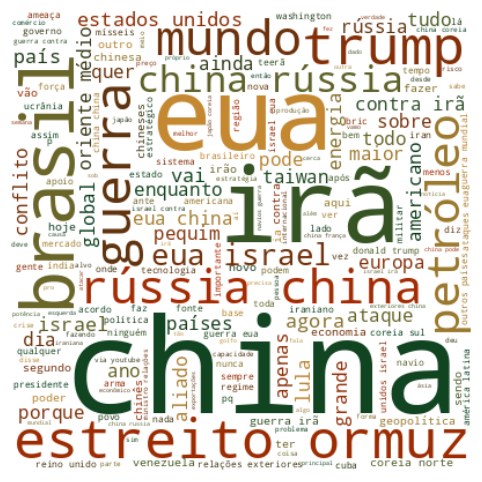

In [17]:
# Gerar nuvem de palavras a partir dos textos pré-processados
texto_unido = " ".join(df['tokens'])  # Use a coluna 'tokens' com os textos limpos
wordcloud_obj = wordcloud.WordCloud(width=400, height=400,
                      background_color='white',
                      max_words=200,
                      stopwords=stop_words, # Use a variável stop_words já definida
                      colormap = cmap_laranja_jade).generate(texto_unido)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_obj, interpolation='bilinear')
plt.axis('off')
plt.show()

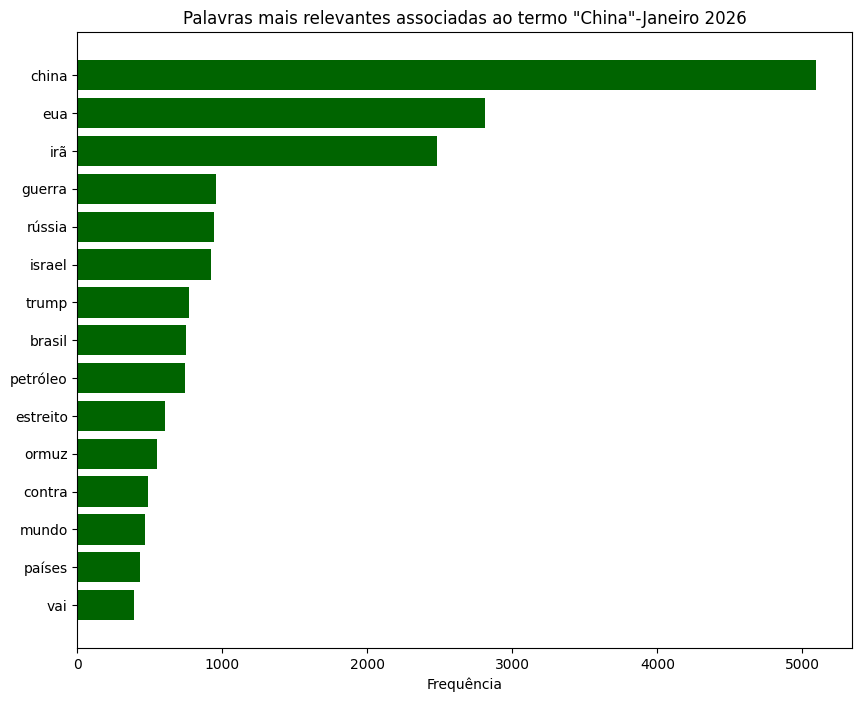

In [18]:
# Filter the dataframe for tweets related to "China"
df_china_filtered = df[df['tokens'].apply(lambda x: 'china' in x.split())]

# Combine all tokens from these filtered tweets
all_words_china = [word for text_string in df_china_filtered['tokens'] for word in text_string.split(" ")]

# Calculate frequency distribution for these words
freq_dist_china = FreqDist(all_words_china)

top_palavras = freq_dist_china.most_common(15)
palavras, vals = zip(*top_palavras)
plt.figure(figsize=(10,8))
plt.barh(palavras, vals, color='darkgreen')
plt.xlabel('Frequência')
plt.title('Palavras mais relevantes associadas ao termo "China"-Janeiro 2026')
plt.gca().invert_yaxis()
plt.show()

In [19]:
import plotly.express as px
import pandas as pd

# 1. Categorize the compound sentiment score
def classify_sentiment(score):
    if score >= 0.05:
        return 'Positivo'
    elif score <= -0.05:
        return 'Negativo'
    else:
        return 'Neutro'

# Create a new column for sentiment categories
df['sentimento_categoria'] = df['sentimento'].apply(classify_sentiment)

# 2. Count the occurrences of each sentiment category
sentiment_counts = df['sentimento_categoria'].value_counts().reset_index()
sentiment_counts.columns = ['sentimento_categoria', 'contagem']


In [21]:


fig = px.bar(sentiment_counts,
             x='sentimento_categoria',
             y=
             color='sentimento_categoria', # Use the categorical column for coloring
             color_discrete_map={'Positivo':'green', 'Neutro':'gray', 'Negativo':'red'},
             title='Gráfico 1: Distribuição de Sentimentos por Categoria')
fig.show()

In [19]:


# 1. Criando os dados para o intervalo solicitado
datas = pd.date_range(start='2026-02-28', end='2026-03-27', freq='D')
# Gerando valores aleatórios de sentimento para ilustrar
sentimento = np.random.uniform(-0.5, 0.4, len(datas))

df = pd.DataFrame({'Data': datas, 'Sentimento': sentimento})


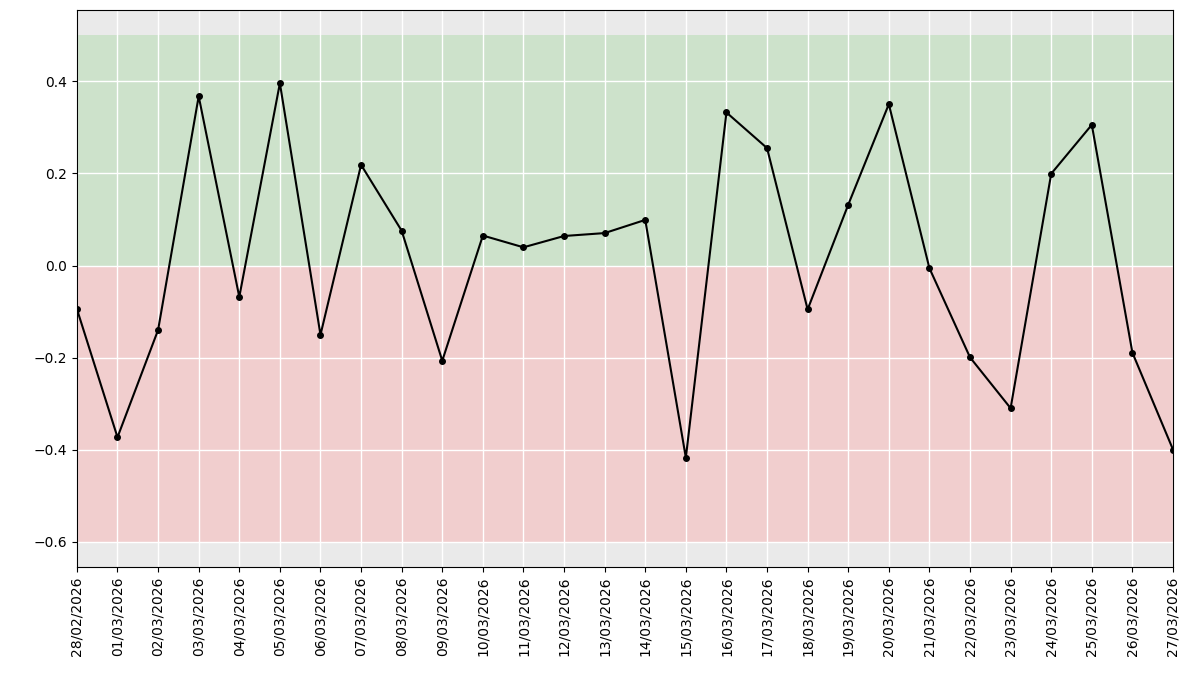

In [26]:
# 1. Criando os dados para o intervalo solicitado
datas = pd.date_range(start='2026-02-28', end='2026-03-27', freq='D')
# Gerando valores aleatórios de sentimento para ilustrar
sentimento_valores = np.random.uniform(-0.5, 0.4, len(datas))

df_plot_data = pd.DataFrame({'Data': datas, 'Sentimento': sentimento_valores})

#grafico séries temporais
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')

ax.axhspan(0, 0.5, facecolor='#c6e0c4', alpha=0.8)
ax.axhspan(-0.6, 0, facecolor='#f4c7c7', alpha=0.8)

ax.plot(df_plot_data['Data'], df_plot_data['Sentimento'], color='black', linewidth=1.5, marker='o', markersize=4)

#Formatação do Eixo X (DIAS), Se ficar poluído, mude para 2 ou 3.
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))

# Eixo e grade
ax.set_facecolor('#eaeaea')
ax.grid(color='white', linestyle='-', linewidth=1)
plt.xticks(rotation=90)

# Títulos e Legendas

plt.xlabel(' ', fontsize=12)
plt.ylabel(' ', fontsize=12)

# Forçar o limite do eixo para o seu período exato
ax.set_xlim(df_plot_data['Data'].min(), df_plot_data['Data'].max())

plt.tight_layout()
plt.show()

**RANDOM FORREST**

In [ ]:
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Remove URLs, menções e hashtags
    text = re.sub(r'http\S+|@\w+|#\w+', '', text)
    # Remove pontuações
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Converte para minúsculas
    text = text.lower()
    # Remove números
    text = re.sub(r'\d+', '', text)
    # Remove stopwords
    stop_words = set(stopwords.words('portuguese'))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

In [ ]:
df['cleaned_tweet'] = df['Tweet_Content'].apply(clean_text)

# Separar dados rotulados e não rotulados
df_labeled = df[df['viés político'].notna()].copy()
df_unlabeled = df[df['viés político'].isna()].copy()

KeyError: 'viés político'

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df_labeled['cleaned_tweet'])
y = df_labeled['viés político']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

Acurácia: 0.5185185185185185

Relatório de Classificação:
               precision    recall  f1-score   support

   contra-irã       0.55      0.67      0.60         9
contra-israel       0.43      0.43      0.43         7
       neutro       0.56      0.50      0.53        10
      neutro        0.00      0.00      0.00         1

     accuracy                           0.52        27
    macro avg       0.38      0.40      0.39        27
 weighted avg       0.50      0.52      0.51        27



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
if not df_unlabeled.empty:
    X_unlabeled = vectorizer.transform(df_unlabeled['cleaned_tweet'])
    rf_predictions = rf_model.predict(X_unlabeled)
    df_unlabeled['viés político (RF)'] = rf_predictions

In [ ]:
df_final_rf = pd.concat([df_labeled, df_unlabeled], ignore_index=True)

# Exportar resultados
output_filename_rf = 'tweets_classificados_rf.csv'
df_final_rf.to_csv(output_filename_rf, index=False, encoding='utf-8-sig')

print("\nResumo da classificação por Random Forest:")
print(df_final_rf['viés político (RF)'].value_counts())



Resumo da classificação por Random Forest:
viés político (RF)
contra-israel    534
contra-irã       386
neutro           324
Name: count, dtype: int64


In [ ]:
pd.set_option('display.max_colwidth', None)
print( df_final_rf[df_final_rf['viés político (RF)'] == 'contra-israel']['cleaned_tweet']  )

135                                                                                                                                                                        israel semanas destruído mísseis balísticoshipersônicos irã guerra próprio provocou parem falar mudança regime irã eua deveriam vez disso pressionar mudança regime israel economizaria dinheiro eua gastariam economia pobres americanos
140                                                                                                                                                                                                                                                                                  irã certamente apressará obter arma nuclear deve obtêla única maneira impedir eua israel bombardeiem todos países oriente médio
141                                                                                                                                                                                           

In [ ]:
feature_names = vectorizer.get_feature_names_out()
importances = rf_model.feature_importances_
top_features = pd.Series(importances, index=feature_names).sort_values(ascending=False)[:20]
print("\nTop 20 features mais importantes:")
print(top_features)


Top 20 features mais importantes:
gaza                0.059865
pessoas             0.057454
irã                 0.053764
israel              0.048469
síria               0.044367
líbano              0.040619
prisão              0.035621
iêmen               0.028277
alguns              0.018481
guerra              0.016706
aceitar             0.016671
eua                 0.016638
iraque              0.015308
mundo               0.014862
terrorista          0.012999
primeiroministro    0.012063
cisjordânia         0.011995
bombardeio          0.011644
bombardeou          0.011105
destruir            0.011056
dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [ ]:
y_ori = y
y_pred = rf_model.predict(X)
cm = confusion_matrix(y_ori, y_pred)
classes = y_test.unique()

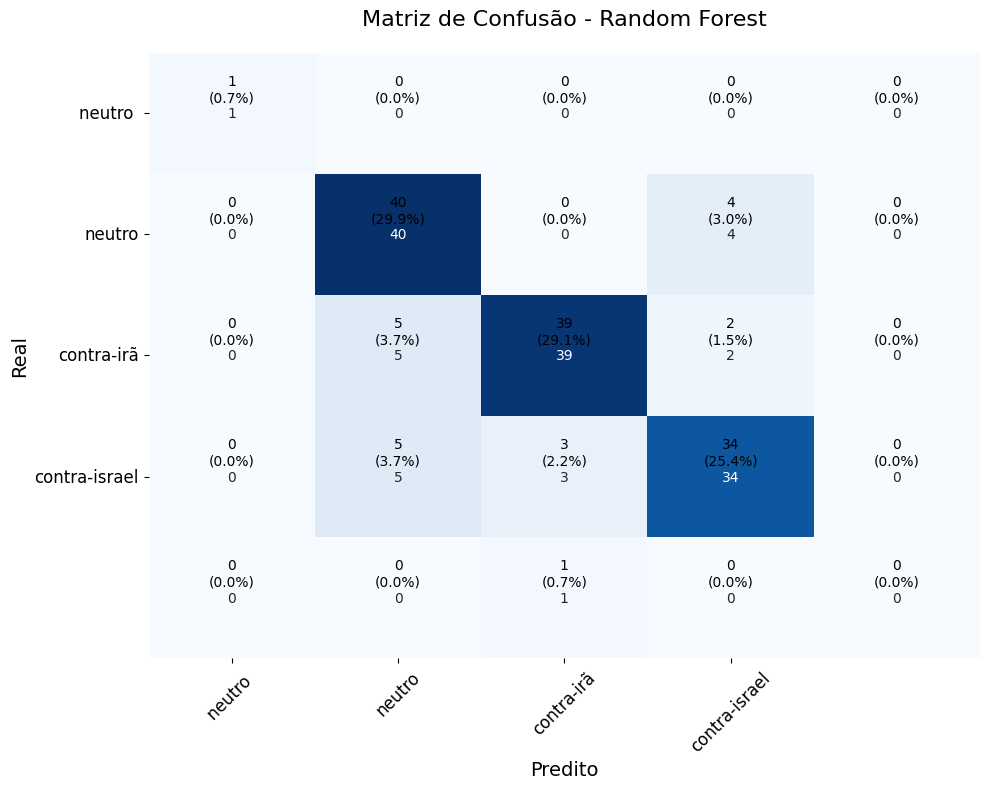

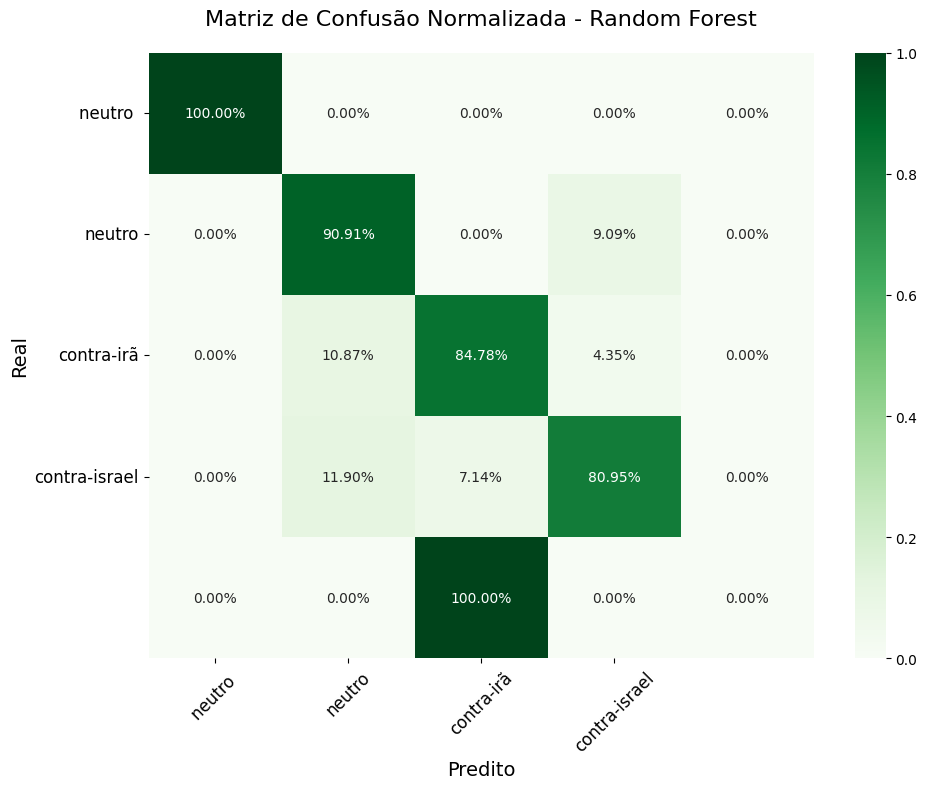

In [ ]:
plt.figure(figsize=(10, 8))

# Plotar heatmap
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=classes,
            yticklabels=classes,
            cbar=False)

# Adicionar rótulos e título
plt.title('Matriz de Confusão - Random Forest', fontsize=16, pad=20)
plt.xlabel('Predito', fontsize=14)
plt.ylabel('Real', fontsize=14)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)

total = cm.sum()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j+0.5, i+0.3, f"{cm[i, j]}\n({cm[i, j]/total:.1%})",
                 ha='center', va='center', color='black', fontsize=10)

# Mostrar a plotagem
plt.tight_layout()
plt.savefig('matriz_confusao_rf.png', dpi=300)
plt.show()

plt.figure(figsize=(10, 8))
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_norm,
            annot=True,
            fmt='.2%',
            cmap='Greens',
            xticklabels=classes,
            yticklabels=classes)

plt.title('Matriz de Confusão Normalizada - Random Forest', fontsize=16, pad=20)
plt.xlabel('Predito', fontsize=14)
plt.ylabel('Real', fontsize=14)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.savefig('matriz_confusao_normalizada_rf.png', dpi=300)
plt.show()